# Titanic 生存预测：建模前数据分析

本 Notebook 完成官方原始数据核验、缺失值处理、异常值诊断、描述性统计、探索性可视化和基础特征准备。分析在此停止，**不训练模型、不生成测试集预测**。

## 结论先行

- 训练集有 891 名乘客，测试集有 418 名乘客；主键唯一且互不重叠。
- 训练集生还率约为 38.4%，类别有一定不均衡，但未达到必须重采样的程度。
- 缺失集中在 `Age`、`Cabin`、`Embarked`，测试集另有 1 个 `Fare` 缺失。
- 客舱缺失率很高，直接填一个“常见舱号”没有事实依据；本项目只提取甲板和有无客舱记录。
- 高票价和高龄记录可能是真实乘客，不直接删除；采用异常标记和 `log(1 + Fare)`。
- 性别、舱位等级、称谓、家庭规模与生还率差异明显，但这些是描述性关联，不等同于因果关系。

## 1. 环境与数据读取

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from prepare_titanic import MODEL_COLUMNS, run_pipeline

result = run_pipeline()
train = result["train"]
test = result["test"]
train_prepared = result["train_prepared"]
test_prepared = result["test_prepared"]

print("训练集:", train.shape)
print("测试集:", test.shape)
train.head()

训练集: (891, 12)
测试集: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. 数据结构与完整性检查

先确认结构、主键、标签和允许值，再讨论清洗方法。

In [2]:
pd.Series(result["checks"], name="结果").to_frame()

,结果
train_columns_match,True
test_columns_match,True
train_rows,891
test_rows,418
sample_rows,418
train_id_unique,True
test_id_unique,True
train_test_id_overlap,0
target_missing,0
target_values_valid,True


In [3]:
missing = pd.concat(
    {
        "训练集缺失数": train.isna().sum(),
        "训练集缺失率": train.isna().mean(),
        "测试集缺失数": test.isna().sum(),
        "测试集缺失率": test.isna().mean(),
    },
    axis=1,
)
missing[missing[["训练集缺失数", "测试集缺失数"]].sum(axis=1) > 0]

,训练集缺失数,训练集缺失率,测试集缺失数,测试集缺失率
Age,177,0.198653,86.0,0.205742
Fare,0,0.000000,1.0,0.002392
Cabin,687,0.771044,327.0,0.782297
Embarked,2,0.002245,0.0,0.000000


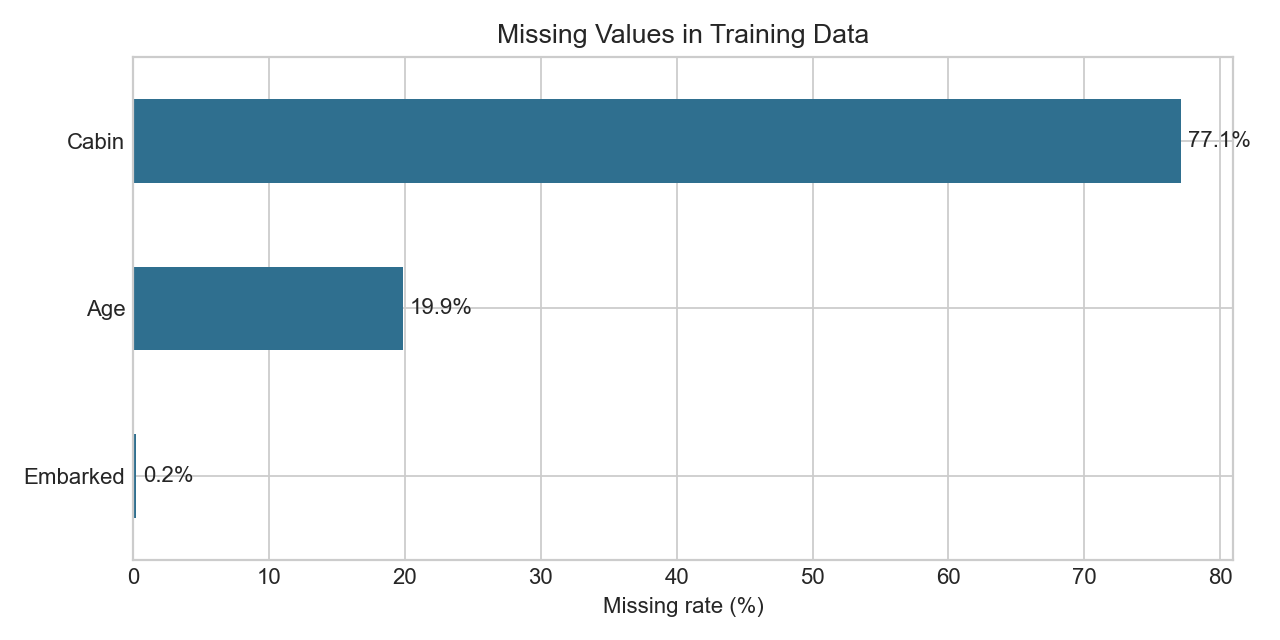

In [4]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "outputs" / "figures" / "01_missing_values.png")))

### 缺失值解释

`Cabin` 的缺失更接近“没有留下客舱记录”，不适合用众数舱号替代。`Age` 与票价是连续量，使用训练集分组中位数比全局均值更稳健，也能避免极端值影响。所有填补都保留 `AgeWasMissing` 或 `FareWasMissing` 标记，模型将来可以判断“缺失本身”是否包含信息。

## 3. 描述性统计

In [5]:
train.describe(include="number").T.round(3)

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000,257.354,1.00,223.500,446.000,668.5,891.000
Survived,891.0,0.384,0.487,0.00,0.000,0.000,1.0,1.000
Pclass,891.0,2.309,0.836,1.00,2.000,3.000,3.0,3.000
Age,714.0,29.699,14.526,0.42,20.125,28.000,38.0,80.000
SibSp,891.0,0.523,1.103,0.00,0.000,0.000,1.0,8.000
Parch,891.0,0.382,0.806,0.00,0.000,0.000,0.0,6.000
Fare,891.0,32.204,49.693,0.00,7.910,14.454,31.0,512.329


In [6]:
categorical = {}
for column in ["Survived", "Pclass", "Sex", "Embarked"]:
    categorical[column] = train[column].value_counts(dropna=False).to_frame("人数")
categorical

{'Survived':            人数
 Survived     
 0         549
 1         342,
 'Pclass':          人数
 Pclass     
 3       491
 1       216
 2       184,
 'Sex':          人数
 Sex        
 male    577
 female  314,
 'Embarked':            人数
 Embarked     
 S         644
 C         168
 Q          77
 NaN         2}

## 4. 生还结果的描述性探索

总体生还率：38.38%


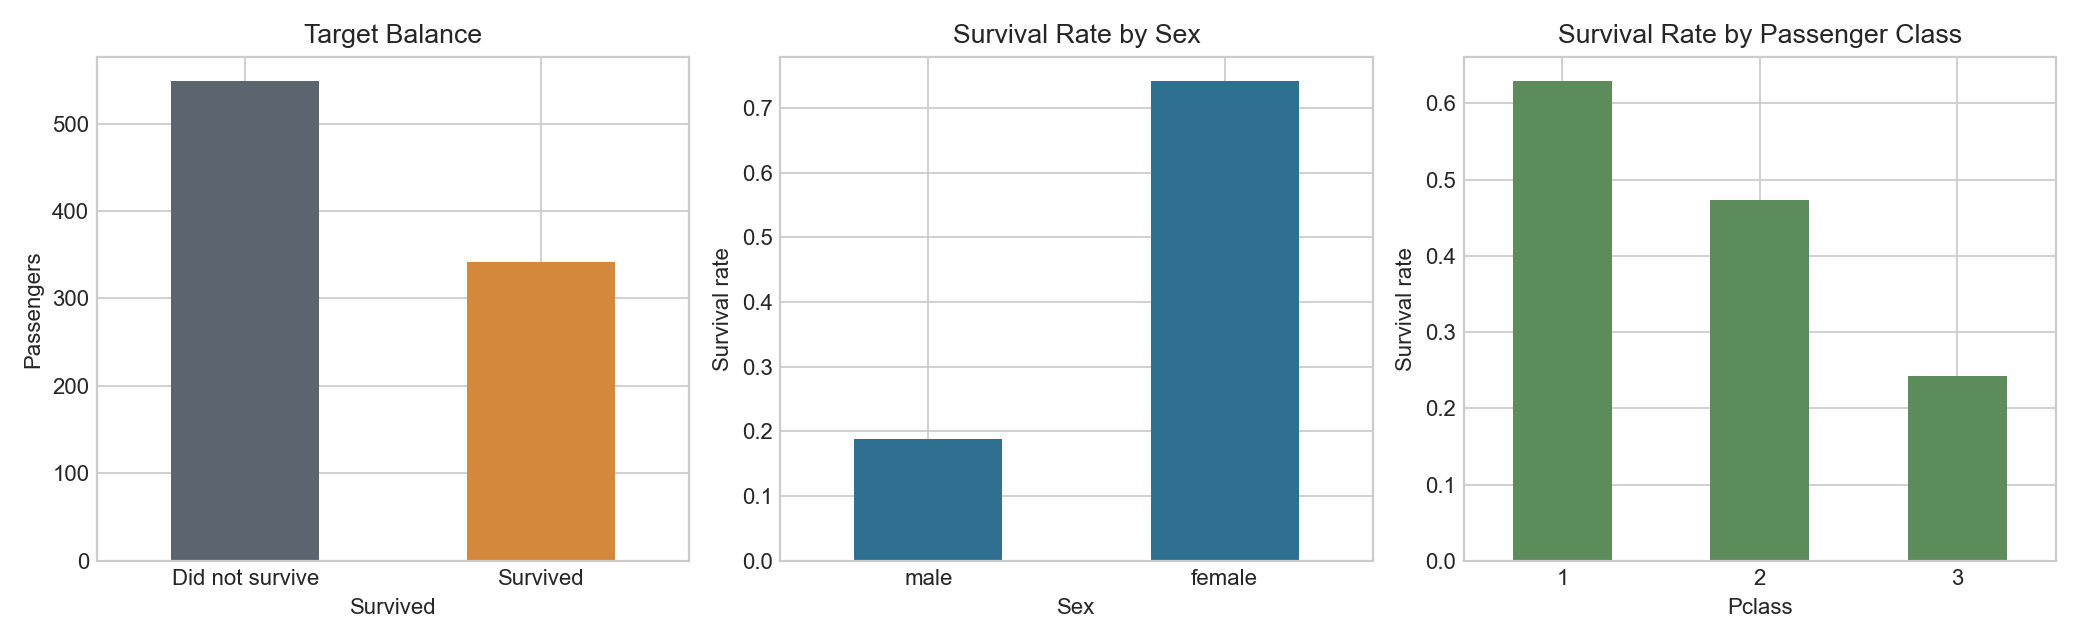

In [7]:
print(f"总体生还率：{train['Survived'].mean():.2%}")
display(Image(filename=str(ROOT / "outputs" / "figures" / "02_survival_overview.png")))

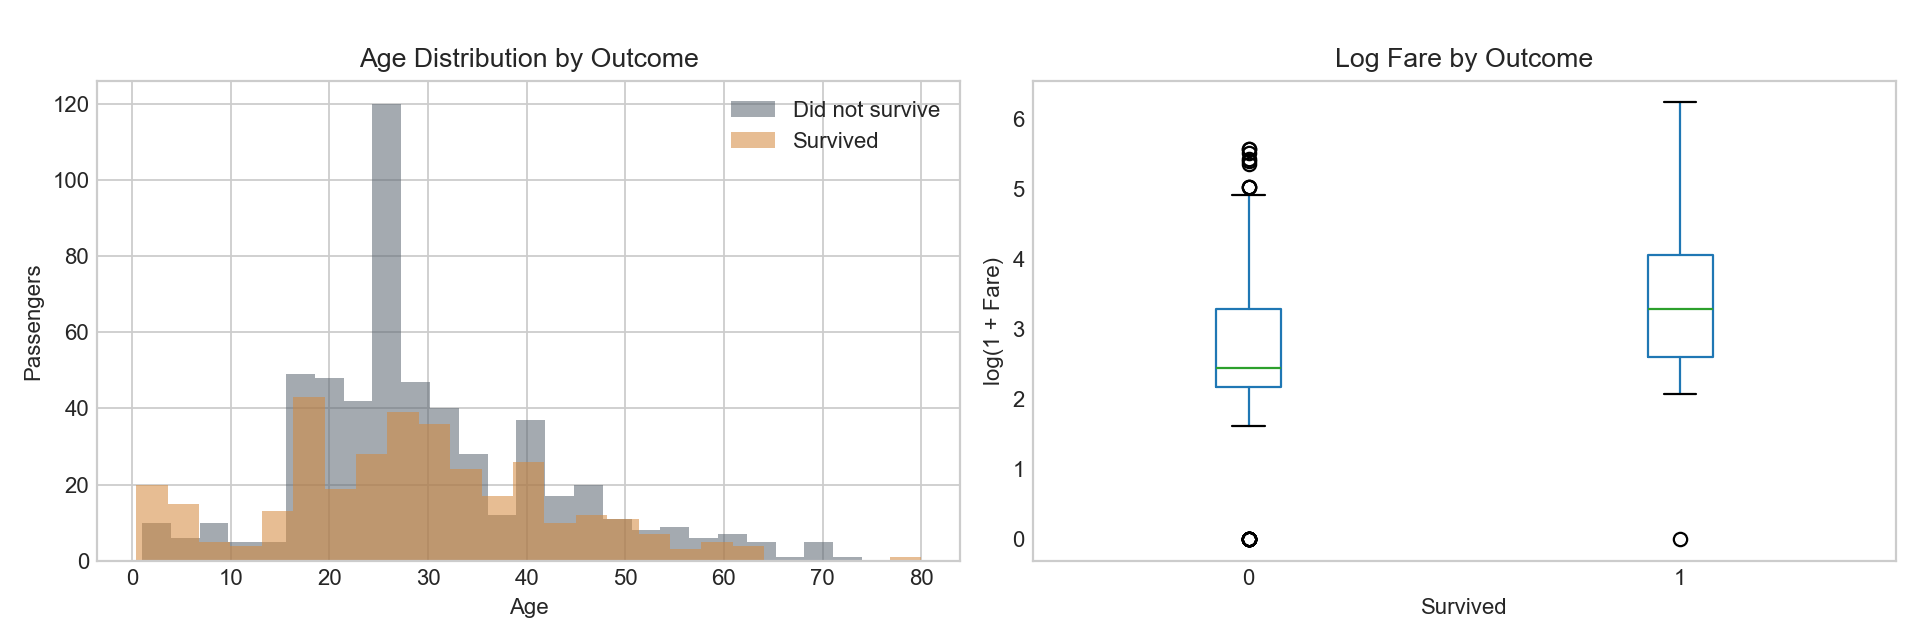

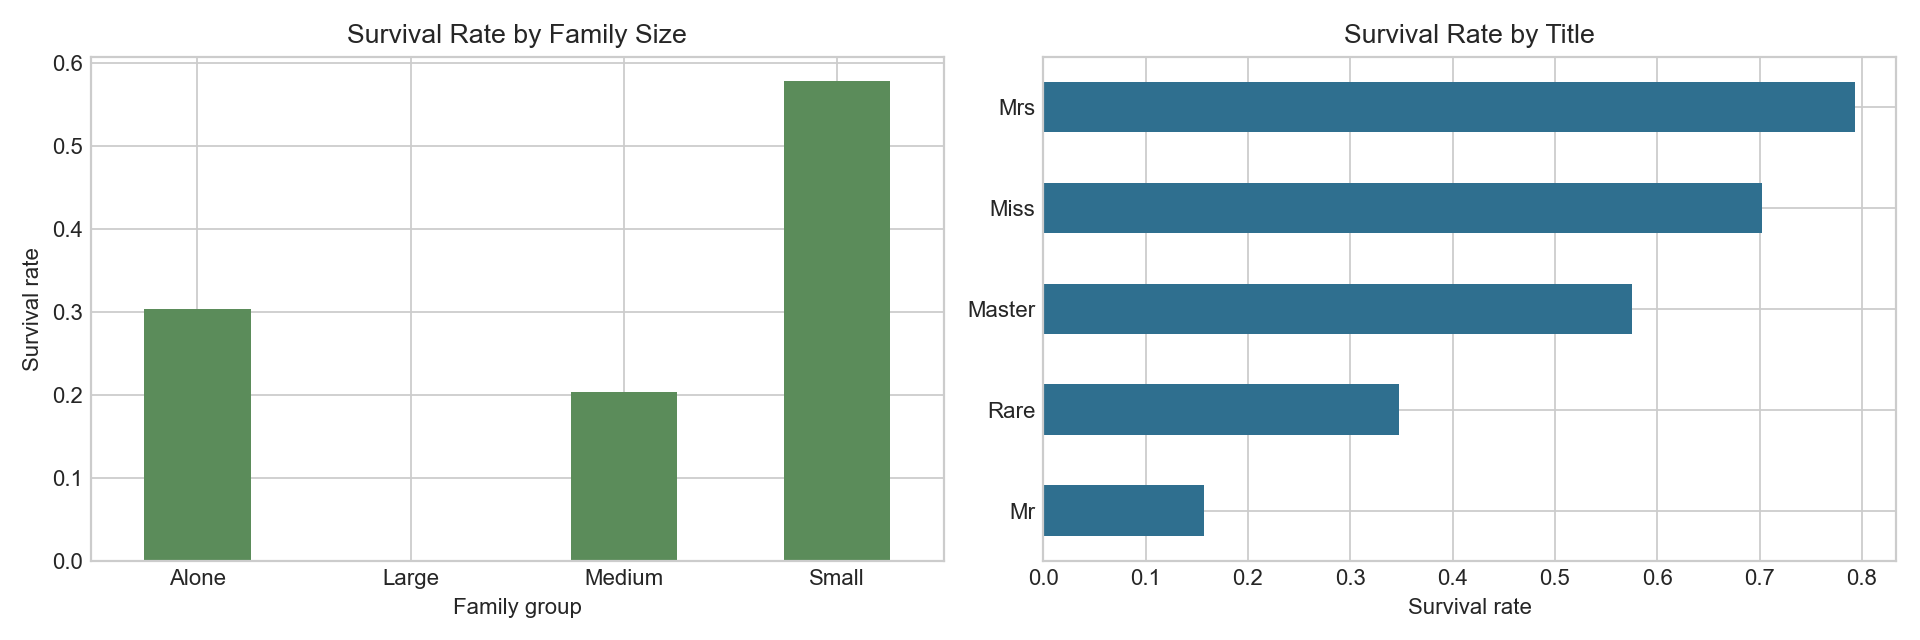

In [8]:
display(Image(filename=str(ROOT / "outputs" / "figures" / "03_age_and_fare.png")))
display(Image(filename=str(ROOT / "outputs" / "figures" / "04_family_and_title.png")))

In [9]:
group_analysis = pd.read_csv(ROOT / "outputs" / "survival_group_analysis.csv")
group_analysis.sort_values(["Feature", "SurvivalRate"], ascending=[True, False]).round(3)

,Feature,Group,Passengers,Survivors,SurvivalRate
18,AgeBand,Child,73,42,0.575
20,AgeBand,Teen,103,49,0.476
17,AgeBand,Adult,224,91,0.406
21,AgeBand,YoungAdult,469,155,0.330
19,AgeBand,Senior,22,5,0.227
23,CabinKnown,1,204,136,0.667
22,CabinKnown,0,687,206,0.300
5,Embarked,C,168,93,0.554
6,Embarked,Q,77,30,0.390
7,Embarked,S,646,219,0.339


### 观察与边界

女性和高等级舱位乘客的生还率明显更高，家庭规模与称谓也显示出分组差异。这些结果适合指导后续特征选择，但不能单凭图表断言因果关系。训练样本仅有 891 行，小样本分组的生还率容易波动，后续必须依靠分层交叉验证判断特征是否真正提升泛化能力。

## 5. 清洗与特征准备

In [10]:
result["audit"]

,Column,TrainMissingBefore,TestMissingBefore,Treatment,Basis
0,Age,177,86,Training-only grouped medians,Title + Pclass + Sex
1,Embarked,2,0,S,Training mode
2,Fare,0,1,Training-only grouped median,Pclass + Embarked
3,Cabin,687,327,Unknown deck,No cabin number fabricated


In [11]:
quality_after = pd.DataFrame({
    "数据集": ["train_model_input", "test_model_input"],
    "行数": [len(train_prepared), len(test_prepared)],
    "模型字段数": [len(MODEL_COLUMNS), len(MODEL_COLUMNS)],
    "缺失单元格": [
        int(train_prepared[MODEL_COLUMNS].isna().sum().sum()),
        int(test_prepared[MODEL_COLUMNS].isna().sum().sum()),
    ],
    "重复主键": [
        int(train_prepared["PassengerId"].duplicated().sum()),
        int(test_prepared["PassengerId"].duplicated().sum()),
    ],
})
quality_after

,数据集,行数,模型字段数,缺失单元格,重复主键
0,train_model_input,891,26,0,0
1,test_model_input,418,26,0,0


## 6. 异常值诊断

In [12]:
outlier_summary = pd.read_csv(ROOT / "outputs" / "outlier_summary.csv")
outlier_summary

,Variable,LowerBound,UpperBound,TrainFlagged,Treatment
0,Age,0.0,60.3750,22,Retained and flagged
1,Fare,0.0,65.6344,116,Retained; LogFare added


In [13]:
outliers = pd.read_csv(ROOT / "outputs" / "outlier_records_for_review.csv")
outliers.head(15)

,PassengerId,Survived,Pclass,Sex,Age,Fare,AgeOutlier,FareOutlier
0,259,1,1,female,35.0,512.3292,0,1
1,680,1,1,male,36.0,512.3292,0,1
2,738,1,1,male,35.0,512.3292,0,1
3,28,0,1,male,19.0,263.0000,0,1
4,89,1,1,female,23.0,263.0000,0,1
5,342,1,1,female,24.0,263.0000,0,1
6,439,0,1,male,64.0,263.0000,1,1
7,312,1,1,female,18.0,262.3750,0,1
8,743,1,1,female,21.0,262.3750,0,1
9,119,0,1,male,24.0,247.5208,0,1


IQR 是筛查规则，不是真伪判决。Titanic 的高票价往往与头等舱或多人共票有关，年龄上限也在合理寿命范围内，因此不删记录。后续线性模型可优先使用 `LogFare`，树模型可以同时比较原始 `Fare` 与衍生变量。

## 7. 建模前数据

In [14]:
print("训练输入：", ROOT / "data" / "prepared" / "train_model_input.csv")
print("测试输入：", ROOT / "data" / "prepared" / "test_model_input.csv")
print("特征数量（不含 PassengerId）：", result["metadata"]["model_feature_count_excluding_id"])
train_prepared[MODEL_COLUMNS + ["Survived"]].head()

训练输入： C:\Users\25294\Desktop\titanic-machine-learning-from-disaster\data\prepared\train_model_input.csv
测试输入： C:\Users\25294\Desktop\titanic-machine-learning-from-disaster\data\prepared\test_model_input.csv
特征数量（不含 PassengerId）： 25


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,...,TicketGroupSize,SurnameGroupSize,FarePerPerson,LogFare,AgeBand,AgeWasMissing,FareWasMissing,FareOutlier,AgeOutlier,Survived
0,1,3,male,22.0,1,0,7.2500,S,Mr,2,...,1,2,7.25000,2.110213,YoungAdult,0,0,0,0,0
1,2,1,female,38.0,1,0,71.2833,C,Mrs,2,...,2,2,35.64165,4.280593,Adult,0,0,1,0,1
2,3,3,female,26.0,0,0,7.9250,S,Miss,1,...,1,1,7.92500,2.188856,YoungAdult,0,0,0,0,1
3,4,1,female,35.0,1,0,53.1000,S,Mrs,2,...,2,2,26.55000,3.990834,YoungAdult,0,0,0,0,1
4,5,3,male,35.0,0,0,8.0500,S,Mr,1,...,1,2,8.05000,2.202765,YoungAdult,0,0,0,0,0


## 8. 下一阶段注意事项

1. 使用分层交叉验证，并同时观察 Accuracy、F1、ROC-AUC 和混淆矩阵。
2. 在正式交叉验证中，把填补、编码和模型放进同一条 Pipeline；每折只学习该折训练数据。
3. 先建立逻辑回归等可解释基线，再比较树模型和集成模型。
4. 模型选择依据交叉验证均值与波动，不依据公开排行榜反复试探。
5. 测试集只在最终模型确定后预测，避免人为读取或拼接外部生还名单。